<a href="https://colab.research.google.com/github/Andrian0s/ML4NLP1-2026-Tutorial-Notebooks/blob/main/tutorials_notebooks_in_class_2026/W03_pipeline_gridsearch_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML4NLP1 - Tutorial W03: Pipelines, Grid Search and Model Interpretability

In W02 you built a first text classifier with `sklearn`: `CountVectorizer`, the `fit`/`transform` discipline, the data-leakage trap, a basic `Pipeline`, `predict_proba` and the confusion matrix. 

In this tutorial we add the tools you need for **Exercise 1, Part I**:

1. **Model selection done right**: why the test set is not for tuning, holdout validation and cross-validation, and the leakage trap inside cross-validation.
2. **Pipelines with several branches**: `TfidfVectorizer` + `LinearSVC`, `get_params()` and the `step__param` naming convention.
3. **Custom transformers**: your own feature extractor as a `sklearn` estimator, combined with the vectoriser through a `FeatureUnion`.
4. **`GridSearchCV`**: searching over vectoriser, transformer and classifier parameters at once, and reading `cv_results_`.
5. **Evaluation** on the held-out test set.
6. **Interpretability**: what the linear model learned, once through its coefficients and once through SHAP values.

Throughout the notebook there are discussion questions marked with 🗒❓.

## 0. Setup

The notebook runs on Google Colab or on your own machine. The versions below are the ones the notebook was tested with; pinning them avoids surprises and makes sure the notebook is reproducible everywhere.

In [1]:
%pip install -q scikit-learn==1.9.1 shap==0.52.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import shap

from sklearn.datasets import fetch_20newsgroups
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

SEED = 42
rng = np.random.RandomState(SEED)

print(f"scikit-learn {sklearn.__version__} | shap {shap.__version__} | numpy {np.__version__} | pandas {pd.__version__}")
NOTEBOOK_START = time.time()

scikit-learn 1.9.1 | shap 0.52.0 | numpy 2.5.3 | pandas 3.0.6


---
## 1. Data: 20 Newsgroups

We use the [20 Newsgroups](https://scikit-learn.org/stable/datasets/real_world.html#the-20-newsgroups-text-dataset) dataset: some 18,000 posts from 20 Usenet discussion groups, collected in the 1990s. To keep the runtime short we take four groups. `sklearn` downloads the data on the first call (~14 MB) and caches it.

Note that `fetch_20newsgroups` returns the labels already as integers (`target`) together with their names (`target_names`). In Exercise 1 your labels are strings; there you will need a [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).

In [3]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=SEED)
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=SEED)

X_train, y_train = twenty_train.data, twenty_train.target   # list of str, array of int
X_test, y_test = twenty_test.data, twenty_test.target
target_names = twenty_train.target_names

print(f"Training documents: {len(X_train)}")
print(f"Test documents:     {len(X_test)}")
print(f"Classes:            {target_names}")

Training documents: 2257
Test documents:     1502
Classes:            ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']


In [4]:
# A DataFrame is convenient for inspection (only for inspection: the models below take the raw lists)
train_df = pd.DataFrame({'text': X_train, 'label': [target_names[i] for i in y_train]})
test_df = pd.DataFrame({'text': X_test, 'label': [target_names[i] for i in y_test]})

train_df['n_chars'] = train_df['text'].str.len()

print("Document length in characters (train):")
print(train_df['n_chars'].describe().round(0), end='\n\n')

print("Class distribution:")
class_distribution = pd.DataFrame({
    'train_count': train_df['label'].value_counts(),
    'train_%': (100 * train_df['label'].value_counts(normalize=True)).round(1),
    'test_count': test_df['label'].value_counts(),
    'test_%': (100 * test_df['label'].value_counts(normalize=True)).round(1),
})
class_distribution

# What can we say aout this dataset...?
# looks pretty balanced...

Document length in characters (train):
count     2257.0
mean      1993.0
std       3548.0
min        125.0
25%        795.0
50%       1235.0
75%       2059.0
max      60713.0
Name: n_chars, dtype: float64

Class distribution:


,train_count,train_%,test_count,test_%
label,,,,
soc.religion.christian,599,26.5,398,26.5
sci.med,594,26.3,396,26.4
comp.graphics,584,25.9,389,25.9
alt.atheism,480,21.3,319,21.2


In [5]:
# Look at one random training document
sample = train_df.sample(1, random_state=SEED).iloc[0]
print(f"LABEL: {sample['label']}\n")
print(sample['text'][:1500])

LABEL: sci.med

From: ray@engr.LaTech.edu (Bill Ray)
Subject: Re: Acutane, Fibromyalgia Syndrome and CFS
Organization: Louisiana Tech University
Lines: 8
NNTP-Posting-Host: ee02.engr.latech.edu
X-Newsreader: TIN [version 1.1 PL8]

Daniel Prince (Daniel.Prince@f129.n102.z1.calcom.socal.com) wrote:

: ... I think they should rename Waco TX to Wacko TX!

I know it is just a joke, but please remember: the people of Waco
did not ask David Koresh to be a lunatic there, he just happened.
Waco is a lovely town.  I would think someone living in the home
of flakes and nut would be more sensitive :-)



### 🗒❓ Class distribution

1. Is the training set balanced? Is the test set distributed like the training set?
2. Why does this matter (a) for accuracy as a metric and (b) for how we split the data into folds below?
3. Look at the document above. Which parts of it are about the *topic*, and which parts are noise from the format (headers, signatures, quoted replies)? Keep this in mind for the interpretability section.

---
## 2. Model selection: validation data and cross-validation

### 2.1 Why not tune on the test set?

The purpose of the test set is to estimate how well the *final* model generalises to unseen data. Every time we look at the test score and then change something (a hyperparameter, a feature, the model), the test set stops being unseen: we are fitting our choices to it, and the final number becomes optimistic. In W02 we saw the same principle at the level of the vectoriser (fitting the vocabulary on the test set). It holds for *every* decision.

So, during development, the test set stays in the drawer and we need another source of numbers.

### 2.2 Holdout validation

The simplest option is to carve a **validation** (or development) set out of the training data, tune on it, and touch the test set once at the very end.

### 2.3 Cross-validation

A single validation split has two problems: we throw away training data, and the score depends on which documents happened to land in the validation split. **k-fold cross-validation** splits the training data into *k* folds, trains *k* models, each with a different fold as validation set, and averages the scores. The estimate is more stable and uses all training data, at the cost of *k* fits instead of one.

The figure below shows the three schemes.

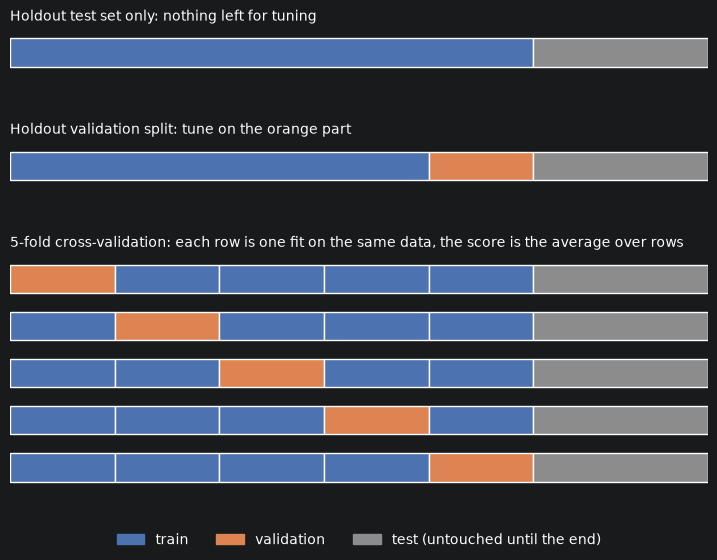

In [6]:
def draw_split_schemes(n_docs=20, k=5):
    # one unit of y per bar everywhere, so all bars have the same height
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), gridspec_kw={'height_ratios': [1, 1, k], 'hspace': 0.6})
    colors = {'train': '#4C72B0', 'val': '#DD8452', 'test': '#8C8C8C'}

    def bar(ax, y, spans):
        for start, end, kind in spans:
            ax.barh(y, end - start, left=start, color=colors[kind], edgecolor='white', height=0.6)

    def finish(ax, n_rows, title):
        ax.set_xlim(0, n_docs); ax.set_ylim(-(n_rows - 1) - 0.5, 0.5)
        ax.set_yticks([]); ax.set_xticks([]); ax.set_frame_on(False)
        ax.set_title(title, loc='left', fontsize=10)

    bar(axes[0], 0, [(0, 15, 'train'), (15, 20, 'test')])
    finish(axes[0], 1, 'Holdout test set only: nothing left for tuning')

    bar(axes[1], 0, [(0, 12, 'train'), (12, 15, 'val'), (15, 20, 'test')])
    finish(axes[1], 1, 'Holdout validation split: tune on the orange part')

    fold = 15 / k
    for i in range(k):
        bar(axes[2], -i, [(j * fold, (j + 1) * fold, 'val' if j == i else 'train') for j in range(k)] + [(15, 20, 'test')])
    finish(axes[2], k, f'{k}-fold cross-validation: each row is one fit on the same data, the score is the average over rows')

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
    fig.legend(handles, ['train', 'validation', 'test (untouched until the end)'], loc='lower center', ncol=3, frameon=False)
    plt.show()

draw_split_schemes()

# Comment on the split:
# For Holdout Vaildation split: Bad, because you "waste" some of your data!!
# And also it will depend on what data you have in this validation set!! You will overfit to THIS
# validation set, when you do hyperparameter tuning!!

# Instead: Better to do 5-fold (or k-fold in general) cross-validation!!
# For validation: We can take the average of the 5 for validation... Is more stable!!
# Plus: you are able to use the ENTIRE training set!!

In `sklearn`, a cross-validation scheme is an object that yields `(train_indices, validation_indices)` pairs. For classification we use `StratifiedKFold`, which keeps the class proportions in every fold (see question 2 above). Passing `shuffle=True` with a fixed `random_state` makes the folds reproducible.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# very nice method from sklearn to use out-of-the-box
# "Stratified": Distribution of classes should be the same in all folds!!
# NOT to get a confusing score; we want classes to be equally distributed in both validation AND train. dataset
# We can then use the returned indices!!

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"fold {fold}: {len(train_idx)} train documents, {len(val_idx)} validation documents, "
          f"class counts in validation fold: {np.bincount(y_train[val_idx])}")

fold 0: 1805 train documents, 452 validation documents, class counts in validation fold: [ 96 117 119 120]
fold 1: 1805 train documents, 452 validation documents, class counts in validation fold: [ 96 117 119 120]
fold 2: 1806 train documents, 451 validation documents, class counts in validation fold: [ 96 117 118 120]
fold 3: 1806 train documents, 451 validation documents, class counts in validation fold: [ 96 117 119 119]
fold 4: 1806 train documents, 451 validation documents, class counts in validation fold: [ 96 116 119 120]


### 2.4 A first cross-validated baseline

The leakage rule from W02 applies inside cross-validation as well: in every fold the vectoriser (and any other data-dependent step) must be fitted on that fold's training part only, so we pass the **`Pipeline`** on the raw texts to `cross_val_score`, `cross_validate` or `GridSearchCV`, never a pre-vectorised matrix.

Our baseline is a `TfidfVectorizer` followed by a `LinearSVC`, a linear support vector machine. Compared to the `CountVectorizer` from W02, TF-IDF down-weights terms that occur in many documents; `sublinear_tf=True` replaces the raw term frequency by `1 + log(tf)`, so a word occurring 50 times does not count 50 times as much as a word occurring once.

In [8]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2, max_features=20000, sublinear_tf=True)),
    ('clf', LinearSVC(random_state=SEED)),
])

# tfidf explanation: Is a different vectorizer!! Idea: Assign score to each word.
# Score will be less, if word appears in many documents; and higher score if word only appears in a few docs.
# idea: capture how representative/ specific a word is!!

# Support Vector Machine: Also learns linear decision boundary/ hyperplane, which separates our classes...!
# learns 1 vs. many classes! "1 against the rest"

# for cross-validation: pass cv object from above!

scores = cross_val_score(pipe, X_train, y_train, cv=cv)
print(f"Accuracy per fold: {scores.round(4)}")
print(f"Mean CV accuracy:  {scores.mean():.4f} ± {scores.std():.4f}")

Accuracy per fold: [0.9757 0.9757 0.9734 0.9712 0.9734]
Mean CV accuracy:  0.9739 ± 0.0017


---
## 3. A Pipeline and its parameters

Every estimator in `sklearn` exposes its hyperparameters through `get_params()`. In a `Pipeline`, the parameters of the steps are reachable with the **`step__param`** naming convention (two underscores). This is the key to `GridSearchCV` later: we address any parameter of any step by its path.

In [9]:
params = pipe.get_params()
print(f"{len(params)} parameters in total. The pipeline-level ones:")
print([k for k in params if '__' not in k], end='\n\n')

# useful for hyperparameter search; to find the best params. that you found...

print("A few step parameters, addressed as step__param:")
for key in ['tfidf__ngram_range', 'tfidf__min_df', 'tfidf__max_features', 'tfidf__analyzer', 'clf__C', 'clf__loss']:
    print(f"  {key:22s} = {params[key]}")

39 parameters in total. The pipeline-level ones:
['memory', 'steps', 'transform_input', 'verbose', 'tfidf', 'clf']

A few step parameters, addressed as step__param:
  tfidf__ngram_range     = (1, 1)
  tfidf__min_df          = 2
  tfidf__max_features    = 20000
  tfidf__analyzer        = word
  clf__C                 = 1.0
  clf__loss              = squared_hinge


In [10]:
# The same convention works for setting parameters, on the pipeline or on a copy of it
pipe.set_params(clf__C=0.5, tfidf__ngram_range=(1, 2))
print(pipe.get_params()['clf__C'], pipe.get_params()['tfidf__ngram_range'])

# ... and we can always reach a fitted step by name
pipe.fit(X_train, y_train)
print(f"Number of features after fitting with unigrams + bigrams (capped by max_features): {len(pipe.named_steps['tfidf'].vocabulary_)}")
pipe.set_params(clf__C=1.0, tfidf__ngram_range=(1, 1));   # back to the defaults for the rest of the notebook

0.5 (1, 2)
Number of features after fitting with unigrams + bigrams (capped by max_features): 20000


### 🗒❓ Pipeline parameters
1. `LinearSVC` has a parameter `C`. Is a large `C` more or less regularisation? (Check the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html).)
2. Why does `pipe.get_params()` also list `tfidf` and `clf` themselves as parameters? (Hint: look at how we replace a whole branch with `'drop'` in Section 5.)

---
## 4. Your own transformer, and combining feature sources

Sometimes the features you want are not offered by any `sklearn` class, for example simple text statistics: how long is the document, how many words does it have, how much of it is upper case? To use such features inside a `Pipeline`, and therefore inside cross-validation and grid search, we write a small class that follows the `sklearn` estimator contract:

- inherit from `BaseEstimator` (gives you `get_params`/`set_params`, so the class works with `GridSearchCV` and `clone`) and `TransformerMixin` (gives you `fit_transform`);
- `__init__` **only stores** its arguments, each under **exactly the same name** as the argument. No computation, no validation, no renaming. `BaseEstimator` inspects the signature of `__init__` to find the hyperparameters;
- `fit(X, y=None)` learns whatever needs learning (here nothing) and `return self`;
- `transform(X)` returns a 2-D array with one row per document;
- `get_feature_names_out()` returns one name per output column. Without it you cannot name your features later, and the interpretability section would show you `x123` instead of `n_words`.

Our transformer has one hyperparameter, `log_scale`: whether to apply `log1p` to the count-like statistics, which are heavily right-skewed.

In [11]:
class TextStats(BaseEstimator, TransformerMixin):
    """Five simple document statistics as numeric features."""

    def __init__(self, log_scale=True):
        self.log_scale = log_scale          # stored under the same name; nothing else happens here

    def fit(self, X, y=None):
        return self                         # nothing to learn from the data

    def transform(self, X):
        rows = []
        for doc in X:
            words = doc.split()
            n_chars, n_words = len(doc), len(words)
            rows.append([
                n_chars, # number of characters
                n_words, # number of words
                sum(ch.isupper() for ch in doc) / max(n_chars, 1), # ratio of uppercase words to whole doc.
                doc.count('!') + doc.count('?'), # number of exclamation and question marks.
                sum(ch.isdigit() for ch in doc) / max(n_chars, 1), # number of digits. (ratio)
            ])
        out = np.asarray(rows, dtype=float)
        if self.log_scale:
            out[:, [0, 1, 3]] = np.log1p(out[:, [0, 1, 3]])   # the three count-like columns
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array(['n_chars', 'n_words', 'upper_ratio', 'n_exclam_quest', 'digit_ratio'])


stats = TextStats()
print(stats.get_params())                     # BaseEstimator found the hyperparameter
print(stats.get_feature_names_out())
print(stats.fit_transform(X_train[:3]).round(2))

{'log_scale': True}
['n_chars' 'n_words' 'upper_ratio' 'n_exclam_quest' 'digit_ratio']
[[6.53 4.48 0.09 1.1  0.05]
 [6.91 5.2  0.03 0.   0.  ]
 [8.07 6.34 0.02 1.39 0.  ]]


### Scaling and `FeatureUnion`

Two things are needed before we can put these numbers next to the TF-IDF features:

1. **Scale.** TF-IDF rows are L2-normalised, so every value lies in [0, 1]. A raw `n_chars` of 3,000 would dominate the linear model. [`MaxAbsScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) divides every column by its maximum absolute value (learned on the training data, so it belongs in the pipeline). Unlike `StandardScaler` it does not centre the data, which keeps sparse matrices sparse.
2. **Concatenate.** A [`FeatureUnion`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.FeatureUnion.html) applies several transformers to the *same* input and concatenates their outputs column-wise. Each branch has a name, and the branch names become prefixes in `get_feature_names_out()`.

The `stats` branch is itself a small `Pipeline` (extract, then scale), so its parameters are addressed as `features__stats__extract__log_scale`.

In [12]:
features = FeatureUnion([
    ('tfidf', TfidfVectorizer(min_df=2, max_features=20000, sublinear_tf=True)),
    ('stats', Pipeline([('extract', TextStats()), ('scale', MaxAbsScaler())])),
])

# we want our features also to be scaled, such that the absolute value does not skew them as much!
# here: MaxAbsScaler is used to divide each number by the max. absolute value?
# Piepline: Output of 1 step -> Input of the next step!
# FeatureUnion: Used to combine features!!

pipe = Pipeline([
    ('features', features),
    ('clf', LinearSVC(random_state=SEED)),
])

pipe.fit(X_train, y_train)

feature_names = pipe.named_steps['features'].get_feature_names_out()
print(f"{len(feature_names)} features. First three: {feature_names[:3]}, last five: {feature_names[-5:]}")

X_train_features = pipe.named_steps['features'].transform(X_train)
print(f"Feature matrix: {type(X_train_features).__name__}, shape {X_train_features.shape}, "
      f"{X_train_features.nnz / np.prod(X_train_features.shape):.2%} non-zero")

print(f"\nCV accuracy with TF-IDF + text statistics: {cross_val_score(pipe, X_train, y_train, cv=cv).mean():.4f}")

18499 features. First three: ['tfidf__00' 'tfidf__000' 'tfidf__0000001200'], last five: ['stats__n_chars' 'stats__n_words' 'stats__upper_ratio'
 'stats__n_exclam_quest' 'stats__digit_ratio']
Feature matrix: csr_matrix, shape (2257, 18499), 0.86% non-zero

CV accuracy with TF-IDF + text statistics: 0.9730


---
## 5. Grid search

We now have hyperparameters in three places: the vectoriser (`ngram_range`, `min_df`, ...), our transformer (`log_scale`) and the classifier (`C`). [`GridSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html) tries every combination in a grid, scores each with cross-validation, and, with `refit=True` (the default), **refits the best combination on the full training set** and stores it as `best_estimator_`.

A useful trick: a branch of a `FeatureUnion` (or a step of a `Pipeline`) is itself a parameter and can be set to the string `'drop'`. Putting `'drop'` into the grid lets us test *with* and *without* the extra features in the same search. Since `log_scale` is meaningless when the branch is dropped, we give the grid as a **list of two dictionaries**; each dictionary spans its own sub-grid.

Keep grids small at first: the number of fits is `(number of combinations) × (number of folds)`, and the runtime grows accordingly. `n_jobs=-1` runs the fits on all available CPU cores.

In [13]:
param_grid = [
    {   # with the text statistics
        'features__tfidf__ngram_range': [(1, 1), (1, 2)],
        'features__stats__extract__log_scale': [True, False],
        'clf__C': [0.1, 1.0],
    },
    {   # without them
        'features__tfidf__ngram_range': [(1, 1), (1, 2)],
        'features__stats': ['drop'],
        'clf__C': [0.1, 1.0],
    },
]

# For each param. we want to try each combination of it... --> For the text WITH statistics:
# 2 Options for each step; 2*2*2 = 8 possible combinations
# For 2nd part: 4 options (2*1*2) (4 different combinations)

# --> In Total: 8+4 = 12 combinations!!
# for each of them: Do 5-fold cross-validation (12*5) !! =60!
# Actually: 61!! Because in the end sklearn does another fit with the ENTIRE training set!
# --> take BEST found hyperparameters to fit it once more for ENTIRE training set!

### 🗒❓ How many fits?
Before running the next cell: how many models will `GridSearchCV` fit in total? Count the combinations in both sub-grids, multiply by the number of folds, and do not forget the final refit.

In [14]:
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)

t0 = time.time()
grid.fit(X_train, y_train)
print(f"Grid search took {time.time() - t0:.0f} s")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid search took 14 s


### Reading the results

`cv_results_` is a dictionary with one entry per candidate; as a `DataFrame` it is much easier to read. Besides the mean score, look at the **standard deviation across folds** (is the best candidate really better than the second, or is the difference within the noise?) and at the fit time.

In [15]:
results = pd.DataFrame(grid.cv_results_)

columns = ['param_features__tfidf__ngram_range', 'param_features__stats', 'param_features__stats__extract__log_scale', 'param_clf__C',
           'mean_test_score', 'std_test_score', 'mean_fit_time', 'rank_test_score']
results = results[columns].sort_values('rank_test_score')
results.columns = [c.replace('param_features__', '').replace('param_', '') for c in results.columns]
results.round(4)

# Question: what score/ metric is used here...?
# Default: Accuracy is used!! e.g. 0.9747 plus std. deviation!
# here: Difference between the first two is just a variation in the dataset...
# WITHIN std. deviation!!
# For example if first place model is MUCH heavier, but score is only within std. deviation of
# 2nd place, it's probably better to use the 2nd model..!

,tfidf__ngram_range,stats,stats__extract__log_scale,clf__C,mean_test_score,std_test_score,mean_fit_time,rank_test_score
6,"(1, 1)",NaN,False,1.0,0.9747,0.0041,0.7390,1
11,"(1, 2)",drop,NaN,1.0,0.9743,0.0062,1.1109,2
10,"(1, 1)",drop,NaN,1.0,0.9739,0.0017,0.3582,3
4,"(1, 1)",NaN,True,1.0,0.9730,0.0047,0.7834,4
5,"(1, 2)",NaN,True,1.0,0.9716,0.0068,1.8258,5
7,"(1, 2)",NaN,False,1.0,0.9708,0.0083,2.3219,6
8,"(1, 1)",drop,NaN,0.1,0.9614,0.0041,0.4457,7
2,"(1, 1)",NaN,False,0.1,0.9601,0.0054,0.6461,8
0,"(1, 1)",NaN,True,0.1,0.9592,0.0057,0.7496,9
3,"(1, 2)",NaN,False,0.1,0.9566,0.0086,1.7664,10


In [16]:
print("Best parameters:", grid.best_params_)
print(f"Best mean CV accuracy: {grid.best_score_:.4f}")
print()
print("best_estimator_ is the pipeline refitted on the whole training set with these parameters:")
print(grid.best_estimator_)

Best parameters: {'clf__C': 1.0, 'features__stats__extract__log_scale': False, 'features__tfidf__ngram_range': (1, 1)}
Best mean CV accuracy: 0.9747

best_estimator_ is the pipeline refitted on the whole training set with these parameters:
Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('tfidf',
                                                 TfidfVectorizer(max_features=20000,
                                                                 min_df=2,
                                                                 sublinear_tf=True)),
                                                ('stats',
                                                 Pipeline(steps=[('extract',
                                                                  TextStats(log_scale=False)),
                                                                 ('scale',
                                                                  MaxAbsScaler())]))])),
                ('clf', LinearSVC

In [17]:
# Did the extra features help? Compare the best row with and without the stats branch.
with_stats = results[results['stats'].isna()]        # the 'stats' column is NaN when the branch was not replaced
without_stats = results[results['stats'] == 'drop']
print(f"Best CV accuracy with text statistics:    {with_stats['mean_test_score'].max():.4f}")
print(f"Best CV accuracy without text statistics: {without_stats['mean_test_score'].max():.4f}")

Best CV accuracy with text statistics:    0.9747
Best CV accuracy without text statistics: 0.9743


### 🗒❓ Grid search results
1. Is the winner clearly better than the runner-up, given the standard deviations?
2. The extra features hardly matter here. Suggest a task where document length or punctuation *would* be informative.
3. Which parameter has the largest effect on the score? Which one on the fit time?

---
## 6. Evaluation on the test set

Now, and only now, we open the drawer. We use `grid.best_estimator_` as it is: it has already been refitted on the whole training set, so there is no need to rebuild the pipeline by hand (and doing so risks forgetting a parameter).

`classification_report` gives precision, recall and F1 per class; the confusion matrix shows *which* classes get confused. With `normalize='true'` each row sums to one, so the cells are recall values and classes of different size are comparable.

In [18]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# For the exercise: need to be creative, which features to use!!
# need to think, if they can actually tell us something about the task at hand!!

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}   (best CV accuracy was {grid.best_score_:.4f})\n")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

Test accuracy: 0.9281   (best CV accuracy was 0.9747)

                        precision    recall  f1-score   support

           alt.atheism      0.967     0.834     0.896       319
         comp.graphics      0.911     0.974     0.942       389
               sci.med      0.948     0.914     0.931       396
soc.religion.christian      0.902     0.972     0.936       398

              accuracy                          0.928      1502
             macro avg      0.932     0.924     0.926      1502
          weighted avg      0.930     0.928     0.927      1502



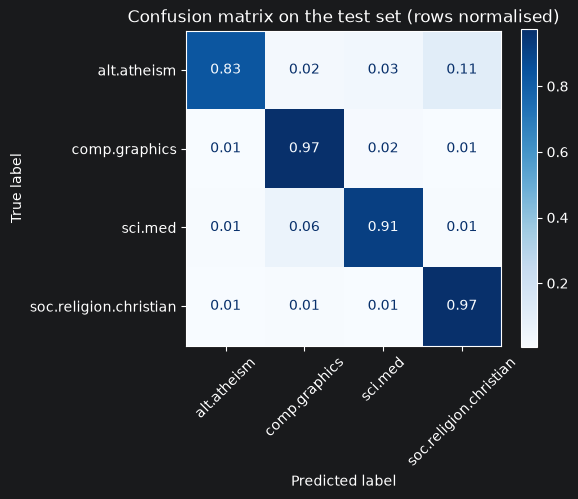

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names,
                                        normalize='true', cmap='Blues', xticks_rotation=45, ax=ax, values_format='.2f')
ax.set_title('Confusion matrix on the test set (rows normalised)')
plt.tight_layout()
plt.show()

# Results: Model sometimes confuses atheism and religion, which makes sense, because it's a similar topic...
# and also computational graphics and science med.

### 🗒❓ Test results
1. The test accuracy is lower than the cross-validation estimate. Is that surprising? Name two reasons why the two numbers can differ.
2. Which pair of classes is confused most often, and why might that be?

---
## 7. Interpretability: what did the model learn?

A linear classifier computes, for each class, a weighted sum of the features. For a one-vs-rest `LinearSVC` with four classes, `coef_` has shape `(4, n_features)`: row *i* holds the weights that push a document towards class *i*. Because our features have names (this is where `get_feature_names_out()` pays off), we can read the weights directly.

### 7.1 Top features per class from the coefficients

In [20]:
clf = best_model.named_steps['clf']
feature_names = best_model.named_steps['features'].get_feature_names_out()
coef = clf.coef_
print(f"coef_ shape: {coef.shape}, feature names: {len(feature_names)}")

def top_features(weights, names, k=15):
    order = np.argsort(weights)[::-1][:k]
    return [(names[i], round(float(weights[i]), 3)) for i in order]

for i, name in enumerate(target_names):
    print(f"\n{name}")
    for feat, w in top_features(coef[i], feature_names):
        print(f"  {w:+.3f}  {feat}")

coef_ shape: (4, 18499), feature names: 18499

alt.atheism
  +1.711  tfidf__atheism
  +1.507  tfidf__keith
  +1.304  tfidf__islamic
  +1.269  tfidf__atheists
  +1.173  tfidf__umd
  +1.159  tfidf__morality
  +1.125  tfidf__mathew
  +1.069  tfidf__wingate
  +1.019  tfidf__caltech
  +0.988  tfidf__writes
  +0.975  tfidf__mantis
  +0.973  tfidf__okcforum
  +0.948  tfidf__rushdie
  +0.935  tfidf__mangoe
  +0.907  tfidf__islam

comp.graphics
  +2.493  tfidf__graphics
  +1.378  tfidf__images
  +1.352  tfidf__image
  +1.332  tfidf__3d
  +1.237  tfidf__software
  +1.210  tfidf__code
  +1.206  tfidf__file
  +1.183  tfidf__files
  +1.116  tfidf__video
  +1.066  tfidf__3do
  +1.030  tfidf__format
  +1.026  tfidf__points
  +1.023  tfidf__card
  +0.980  tfidf__ftp
  +0.975  tfidf__windows

sci.med
  +1.598  tfidf__doctor
  +1.481  tfidf__msg
  +1.421  tfidf__pitt
  +1.374  tfidf__disease
  +1.331  tfidf__health
  +1.197  tfidf__treatment
  +1.125  tfidf__cancer
  +1.121  tfidf__medical
  +1.010  tfi

Most of the top features are what we would hope for (`graphics`, `doctor`, `atheism`, `church`). Some are not: person names, e-mail domains and other pieces of the newsgroup headers also carry high weights. The model has learned *who posts where*, which works on this test set but says nothing about the topic.

If the winning configuration kept the `stats` branch, the five statistics appear in the list with a `stats__` prefix. If it was dropped, we can still look at what they would contribute: `clone` the best pipeline, switch the branch back on, and fit. This is only for inspection; the model we evaluate remains `best_model`.

In [21]:
from sklearn.base import clone

if any(n.startswith('stats__') for n in feature_names):
    inspect_model = best_model
    print("The best model uses the text statistics.")
else:
    inspect_model = clone(best_model).set_params(
        features__stats=Pipeline([('extract', TextStats()), ('scale', MaxAbsScaler())]))
    inspect_model.fit(X_train, y_train)
    print("The best model dropped the text statistics; refitted a copy with them for inspection only.")

names_inspect = inspect_model.named_steps['features'].get_feature_names_out()
coef_inspect = inspect_model.named_steps['clf'].coef_
stats_cols = [i for i, n in enumerate(names_inspect) if n.startswith('stats__')]

stats_table = pd.DataFrame(coef_inspect[:, stats_cols], index=target_names,
                           columns=[names_inspect[i].replace('stats__', '') for i in stats_cols]).round(3)
print("\nCoefficients of the text statistics per class (after MaxAbsScaler):")
stats_table

The best model uses the text statistics.

Coefficients of the text statistics per class (after MaxAbsScaler):


,n_chars,n_words,upper_ratio,n_exclam_quest,digit_ratio
alt.atheism,0.283,0.311,0.269,0.169,0.172
comp.graphics,-0.546,-0.496,0.520,0.393,0.403
sci.med,0.449,0.173,-0.541,-0.186,-0.186
soc.religion.christian,-0.790,-0.681,-0.516,-0.465,-0.696


### 7.2 SHAP values

The coefficients tell us how the model weighs a feature *in general*. They do not tell us what mattered for a **particular** document: a feature with a large weight contributes nothing if it does not occur in the document, and a feature with a modest weight can matter a lot if it is very frequent.

[SHAP](https://shap.readthedocs.io/) (SHapley Additive exPlanations) attributes a prediction to the individual features by asking how the output changes when a feature takes its actual value instead of a *baseline* value. For a linear model the answer has a closed form: the SHAP value of feature *j* for document *x* is

$$\phi_j(x) = w_j \,(x_j - \mathbb{E}[x_j]),$$

where the expectation is taken over a **background** sample of documents. So the SHAP value is the coefficient *scaled by how unusual the feature value is* in this document. `shap.LinearExplainer` implements exactly this.

Two practical points:

- SHAP works with dense arrays. Our TF-IDF matrix is sparse, and densifying all of it would be wasteful (2,257 × 20,000 values). We therefore densify only a **small background sample** (100 training documents) and a **subset of the test set**; that is all SHAP needs.
- `LinearSVC` has no `predict_proba`; its raw scores come from `decision_function`. The SHAP values explain these scores, one set per class.

In [22]:
features_step = best_model.named_steps['features']

background_idx = rng.choice(len(X_train), size=100, replace=False)
X_background = features_step.transform([X_train[i] for i in background_idx]).toarray()

explain_idx = rng.choice(len(X_test), size=100, replace=False)
X_explain = features_step.transform([X_test[i] for i in explain_idx]).toarray()

print(f"Background: {X_background.shape}, {X_background.nbytes / 1e6:.0f} MB dense")
print(f"To explain: {X_explain.shape}")

explainer = shap.LinearExplainer(clf, X_background, feature_names=feature_names)
shap_values = explainer(X_explain)
print(f"SHAP values: {shap_values.shape}  (documents × features × classes)")

Background: (100, 18499), 15 MB dense
To explain: (100, 18499)
SHAP values: (100, 18499, 4)  (documents × features × classes)


**Beeswarm plots.** One plot per class, one dot per document and feature, features sorted by their mean absolute SHAP value. The x-position is the SHAP value (right pushes towards the class, left away from it); the colour is the feature value (red = high TF-IDF weight in that document). Text features are sparse: most words are absent from most documents, so for every feature the majority of dots sit near zero and only the few documents containing the word spread out. The bottom row sums up all remaining features.

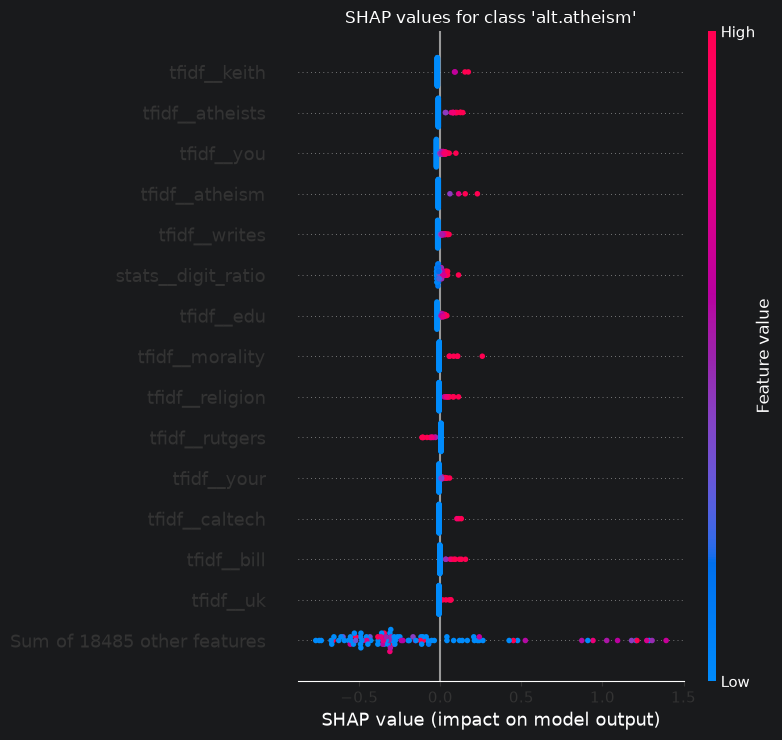

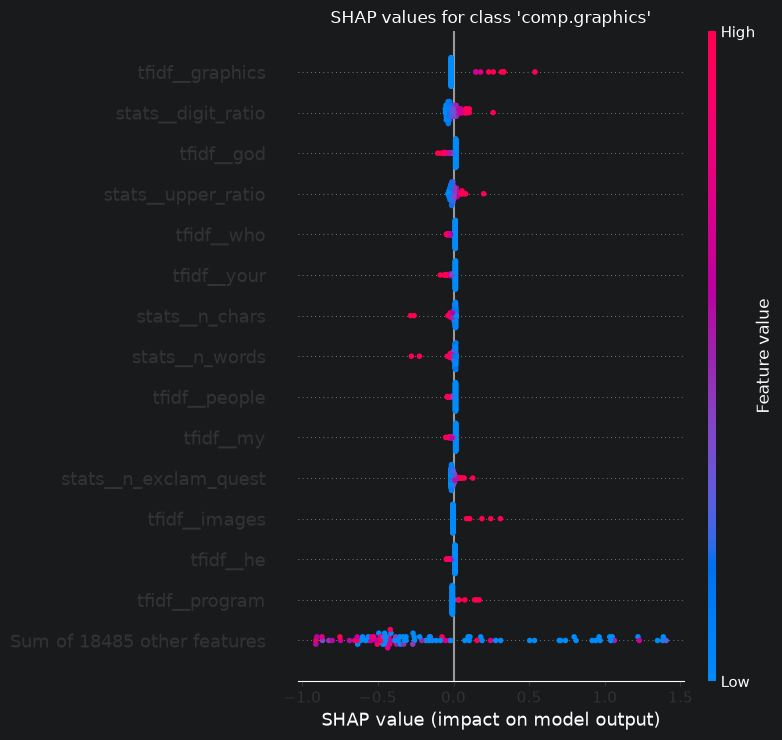

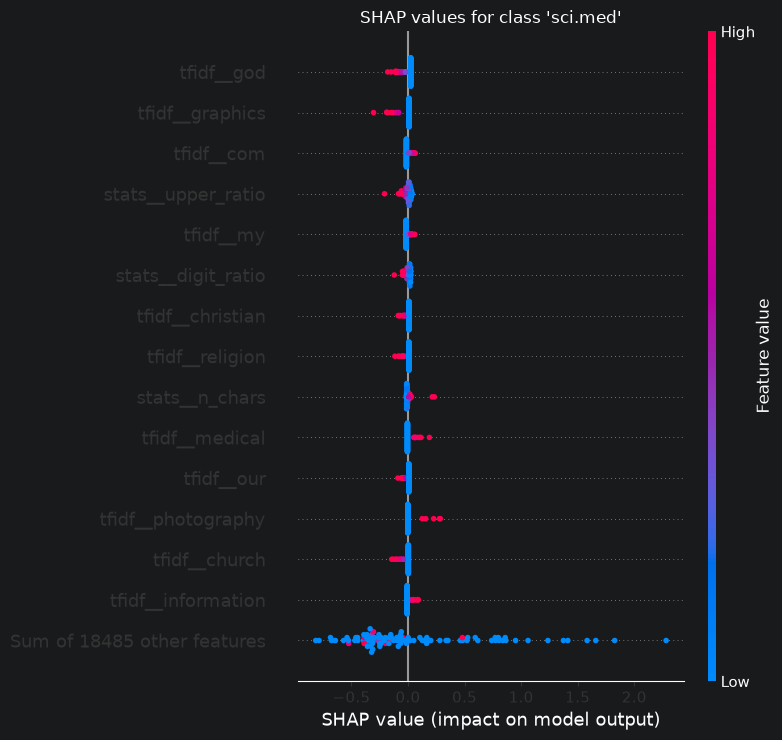

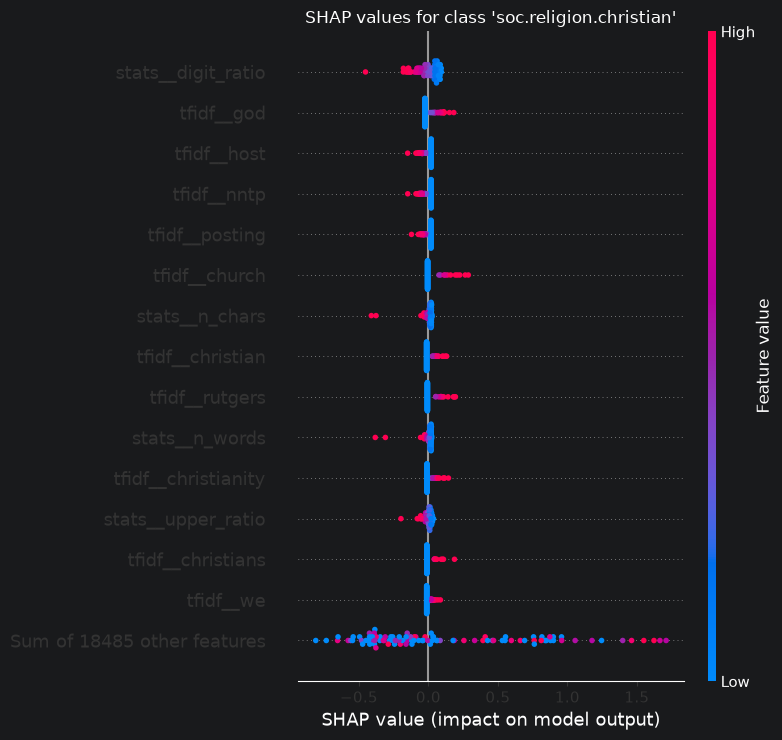

In [23]:
for i, name in enumerate(target_names):
    shap.plots.beeswarm(shap_values[:, :, i], max_display=15, show=False)
    plt.title(f"SHAP values for class '{name}'")
    plt.tight_layout()
    plt.show()

**A local explanation.** Let's pick one of the explained test documents (a misclassified one, if there is any) and see which features drove the score of the predicted class. The waterfall plot starts from the baseline (the average score over the background) and adds the SHAP values one by one.

In [24]:
y_explain = y_test[explain_idx]
pred_explain = clf.predict(X_explain)
wrong = np.flatnonzero(pred_explain != y_explain)
j = int(wrong[0]) if len(wrong) else 0
predicted_class = int(pred_explain[j])

print(f"Document {explain_idx[j]} of the test set. True label: {target_names[y_explain[j]]}, "
      f"predicted: {target_names[predicted_class]}")
print("Decision scores per class:", dict(zip(target_names, clf.decision_function(X_explain[j:j + 1])[0].round(2).tolist())))
print("\n" + X_test[explain_idx[j]][:800] + "\n[...]")

Document 220 of the test set. True label: alt.atheism, predicted: soc.religion.christian
Decision scores per class: {'alt.atheism': -0.04, 'comp.graphics': -1.29, 'sci.med': -1.18, 'soc.religion.christian': 0.06}

From: tgk@cs.toronto.edu (Todd Kelley)
Subject: Re: Faith and Dogma
Organization: Department of Computer Science, University of Toronto
Lines: 56

>In  <1r1mr8$eov@aurora.engr.LaTech.edu> ray@engr.LaTech.edu (Bill Ray)
>wrote:
>
>Faith and dogma are inevitable.  Christians merely understand and admit
>to the fact.  Give me your proof that no God exists, or that He does.  
>Whichever position you take, you are forced to do it on faith.  It does
>no good to say you take no position, for to show no interest in the 
>existence of God is to assume He does not exist.

Consider special relativity.  It hasn't be proved, nor has it been
disproved.  No one has a proof one way or the other, but many people
are interested in it!
 
I've satisfied myself that nothing could indicate absolut

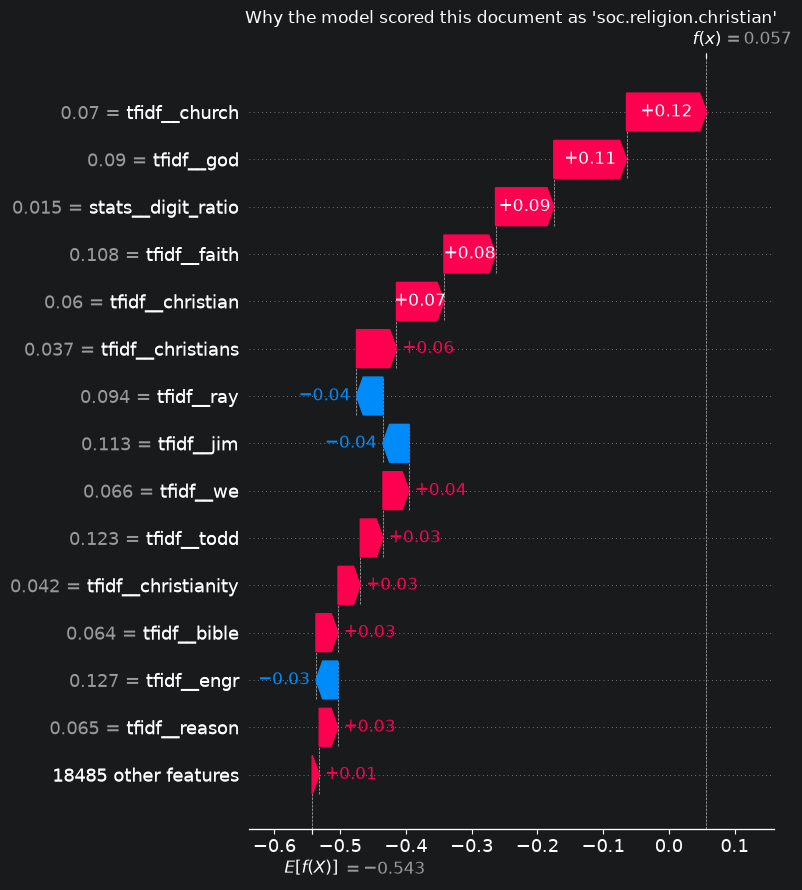

In [25]:
shap.plots.waterfall(shap_values[j, :, predicted_class], max_display=15, show=False)
plt.title(f"Why the model scored this document as '{target_names[predicted_class]}'")
plt.tight_layout()
plt.show()

### 🗒❓ Coefficients versus SHAP values
1. Compare the top-15 lists from Section 7.1 with the beeswarm plots. Which features rank high in one but not in the other? Use the formula above to explain the difference.
2. Several highly weighted features are header artefacts (names, e-mail domains). Is this a problem for the reported test accuracy? For using the model on new posts? What could you change in the data loading to find out? (Hint: `fetch_20newsgroups` has a `remove` argument.)
3. In Exercise 1 you are asked for the most important features per language. Which of the two views, coefficients or SHAP, answers that question, and what do you need in your pipeline so that the features have readable names?

---
> **In Exercise 1 you will use `LogisticRegression`; its hyperparameters differ from `LinearSVC`, so read its [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) before building the grid.** In particular, in `scikit-learn` ≥ 1.8 the regularisation type is controlled with `C` and `l1_ratio` (the `penalty` argument is deprecated), and not every `solver` supports every combination.

## Summary

- The test set is for the final number only. Tune with **cross-validation**, and cross-validate the **whole `Pipeline`** on raw text so that every data-dependent step is fitted inside each fold.
- `get_params()` and the `step__param` convention address any parameter of any step; nested steps just add another `__`.
- A **custom transformer** needs `BaseEstimator` + `TransformerMixin`, an `__init__` that only stores its arguments under the same names, `fit` returning `self`, a 2-D `transform`, and `get_feature_names_out`.
- **`FeatureUnion`** concatenates feature sources; scale numeric features (`MaxAbsScaler`) before mixing them with TF-IDF; a branch set to `'drop'` inside the grid tests the model with and without it.
- **`GridSearchCV`** scores every combination with cross-validation and refits the best one; read `cv_results_` as a `DataFrame` and use `best_estimator_` directly.
- **Coefficients** show the global weight of each feature; **SHAP values** show what mattered for a given document (`coefficient × deviation from the background`). Both need named features.

## What to explore next

- Vectorisers have an **`analyzer`** parameter: `'word'` is the default, `'char'` and `'char_wb'` build character n-grams instead. Think about which unit of analysis suits which task, and how `ngram_range` interacts with it.
- `fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))` strips the artefacts we saw in Section 7. How much accuracy is left when the model has to rely on the content?
- `TfidfVectorizer` has many more knobs: `stop_words`, `max_df`, `binary`, `norm`. Add one at a time to the grid and watch the fit time.
- For larger grids, `RandomizedSearchCV` samples combinations instead of trying all of them.
- SHAP offers other explainers (`shap.Explainer` picks one for you) and other plots (`shap.plots.bar`, `shap.plots.heatmap`), see the [API documentation](https://shap.readthedocs.io/en/latest/api.html).

In [26]:
print(f"Total notebook runtime: {time.time() - NOTEBOOK_START:.0f} s")

Total notebook runtime: 37 s
